In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sklearn.metrics as skm
from matplotlib import pyplot as plt
import glob



In [4]:
path = Path('/home/brian/odrive/project_data/ASinghi-068/data/biliseq_he_class/proc/new_test_data/v7/tiles_model/resnet18_10fold_10rep_500bal_5ft/infer_csv')
ens = pd.read_csv(path.joinpath('fold_summary.csv'))
ens.head()

,Unnamed: 0,slide,class,p1_fold_44,p1_fold_15,p1_fold_89,p1_fold_65,p1_fold_34,p1_fold_96,p1_fold_3,...,p1_fold_26,p1_fold_49,p1_fold_77,p1_fold_84,p1_fold_2,p1_fold_39,p1_fold_56,p1_fold_68,mean_ppos,pred_is_pos_0p5
0,0,1010160,neg,0.217656,0.202637,0.311718,0.173595,0.226640,0.220184,0.200565,...,0.331409,0.382562,0.152291,0.273234,0.188241,0.224194,0.104971,0.304401,0.224704,False
1,1,1010161,pos,0.794573,0.819218,0.865702,0.861729,0.880784,0.859625,0.781105,...,0.872139,0.865745,0.808369,0.877740,0.871281,0.896520,0.824905,0.827675,0.854759,True
2,2,1010162,pos,0.629095,0.583467,0.648632,0.675389,0.740385,0.689045,0.574873,...,0.691670,0.705472,0.613839,0.656423,0.721402,0.753235,0.668335,0.616651,0.665533,True
3,3,1010163,pos,0.480380,0.508917,0.588209,0.582484,0.603736,0.588802,0.502047,...,0.579762,0.588551,0.489272,0.578765,0.613827,0.645139,0.552990,0.527343,0.572755,True
4,4,1010164,neg,0.359616,0.306766,0.406061,0.323311,0.465120,0.364088,0.300857,...,0.344486,0.390920,0.333418,0.393748,0.364003,0.395899,0.406151,0.291923,0.365156,False


0.7567567567567568
[[10  7]
 [ 2 18]]
% Correct 0.7567567567567568


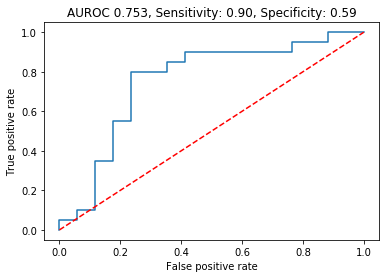

<Figure size 432x288 with 0 Axes>

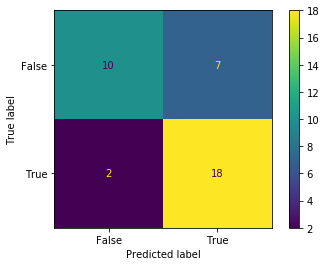

In [10]:
m_p1 = ens.loc[:,'mean_ppos']
true_pos = np.array(ens.loc[:,'class'])=='pos'

pred_pos = m_p1 > 0.5
use = ~np.isnan(m_p1)

print(np.sum(pred_pos[use] == true_pos[use]) / np.sum(use) )

fpr,tpr,thresh =skm.roc_curve(true_pos[use],m_p1[use])
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--r')
c=skm.confusion_matrix(true_pos[use],pred_pos[use])

auc=skm.auc(fpr,tpr)

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
print(c)
tn=c[0][0]
tp=c[1][1]
fn=c[1][0]
fp=c[0][1]

sensitivity = tp/(tp + fn) #True pos / all positive
# print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
# print('specificity',specificity) #True neg / all negative
plt.title('AUROC %1.3f, Sensitivity: %1.2f, Specificity: %1.2f'% (auc,sensitivity,specificity))

f=plt.figure();
b=skm.ConfusionMatrixDisplay.from_predictions(true_pos,pred_pos)
print('% Correct', (tp+tn) / len(true_pos))